In [1]:
from dynamicTasteDistortion.scripts.vis import plot_metric_comparison, plot_metrics_smoothed

## Resultados dos experimentos com movielens1m usando N = 500 e l = 5


* Com preference acquisition ($\alpha = 0.1$)
* Com forgetting baseado em curva de aprendizado
* Medindo MAP
* Medindo diversidade
* Provavelmente a versão final do código

In [2]:
bpr_debiased = "experiments/bpr_unbiased_uncalibrated.yaml"
bpr_biased = "experiments/bpr_classic_uncalibrated.yaml"
random_rec = "experiments/random_rec_uncalibrated.yaml"
most_popular = "experiments/most_popular_uncalibrated.yaml"

# Calibrated ones
bpr_biased_calibrated_constant = "experiments/bpr_classic_calibrated_constant.yaml"
bpr_biased_calibrated_time = "experiments/bpr_classic_calibrated_time_based.yaml"

bpr_debiased_calibrated_constant = "experiments/bpr_unbiased_calibrated_constant.yaml"
bpr_debiased_calibrated_time = "experiments/bpr_unbiased_calibrated_time_based.yaml"


## MRR (non calibrated v calibrated)

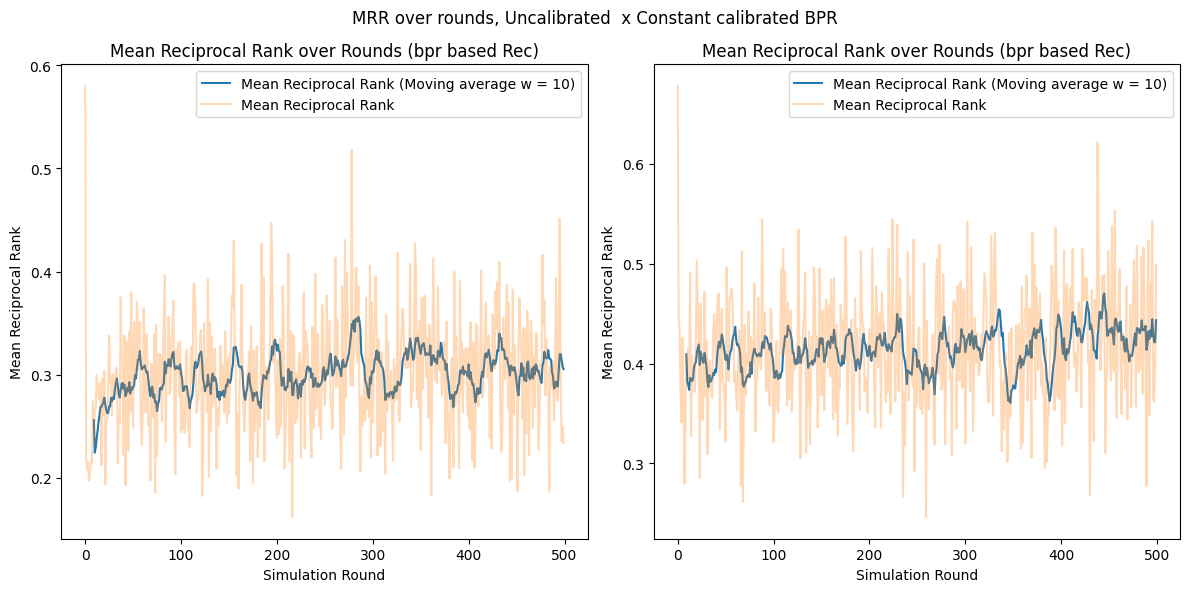

In [14]:
plot_metric_comparison(bpr_debiased, bpr_debiased_calibrated_constant, metric_name="mrr", title="MRR over rounds, Uncalibrated  x Constant calibrated BPR", graph="line", plot_retrain_points=False,  window_size=10)

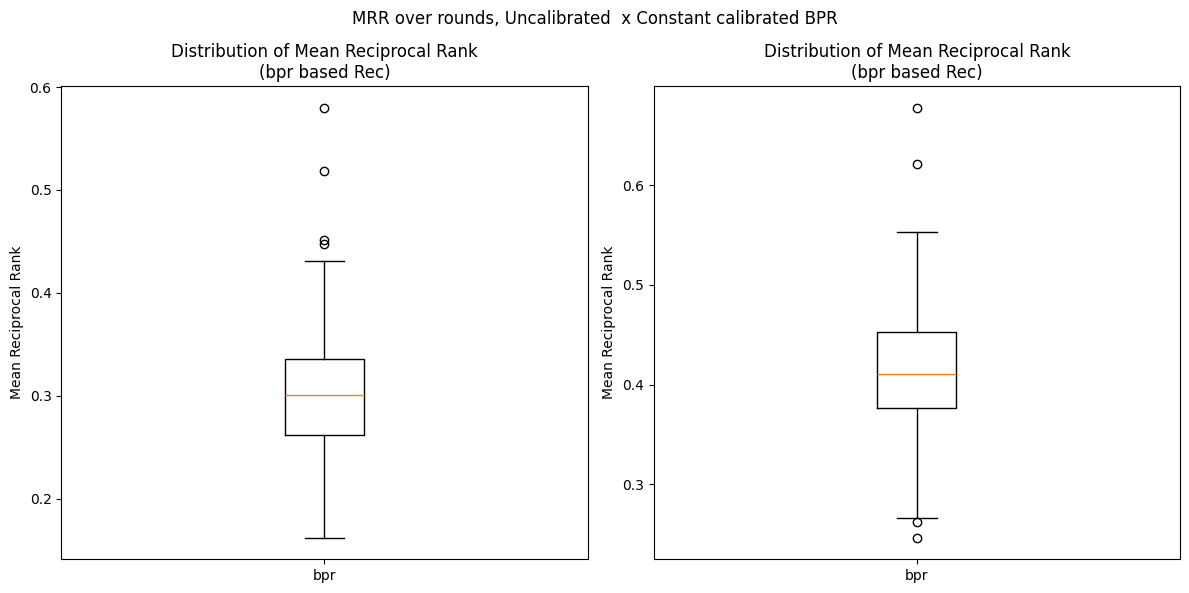

In [15]:
plot_metric_comparison(bpr_debiased, bpr_debiased_calibrated_constant, metric_name="mrr", title="MRR over rounds, Uncalibrated  x Constant calibrated BPR", graph="box", plot_retrain_points=False,  window_size=10)

In [ ]:
plot_metric_comparison(bpr_debiased, random_rec, metric_name="mrr", title="MRR over rounds, Uncalibrated BPR x Random Rec", graph="line", plot_retrain_points=False,  window_size=10)

## Checking out MAP @ k (non calibrated v calibrated)


Bem estranho o MAP ser maior pro caso calibrado... talvez seja um erro de design: a calibração force a recomendação a ter itens que tão no oracle? Preciso pensar melhor essa metrica



Acho que é isso mesmo. O histórico inicial do usuário é totalmente baseado no click_matrix. Click_matrix foi gerado baseado no oráculo. Eu calibro em relação a esse cara. Logo, eu forço as top primeiras posições a terem uma distribuições de genero parecida com h_0.


Então aqui me parece ter um leakage.


Me parece que MRR é uma métrica que faz mais sentido: eu mediria qual a posição media do clique do usuario. Dai eu uso o round_df como test_df? Porque eu de fato sei o que o usuário clicou.

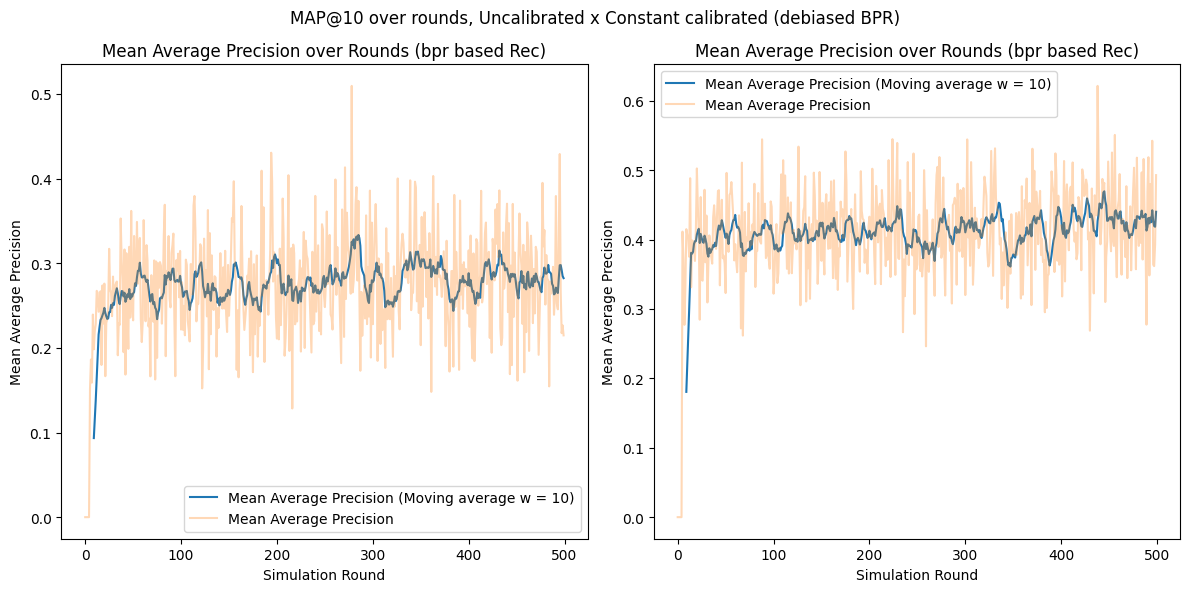

In [4]:
plot_metric_comparison(bpr_debiased, bpr_debiased_calibrated_constant, metric_name="map", title="MAP@10 over rounds, Uncalibrated x Constant calibrated (debiased BPR)", graph="line", plot_retrain_points=False,  window_size=10)

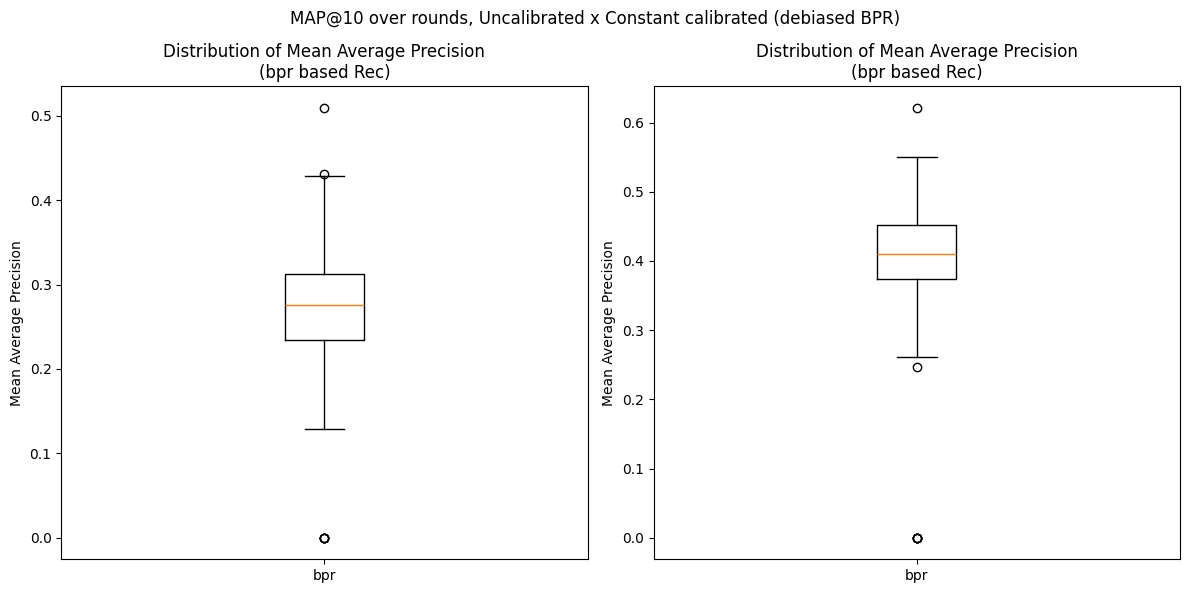

In [13]:
plot_metric_comparison(bpr_debiased, bpr_debiased_calibrated_constant, metric_name="map", title="MAP@10 over rounds, Uncalibrated x Constant calibrated (debiased BPR)", graph="box", plot_retrain_points=False,  window_size=10)

## Catalog coverage

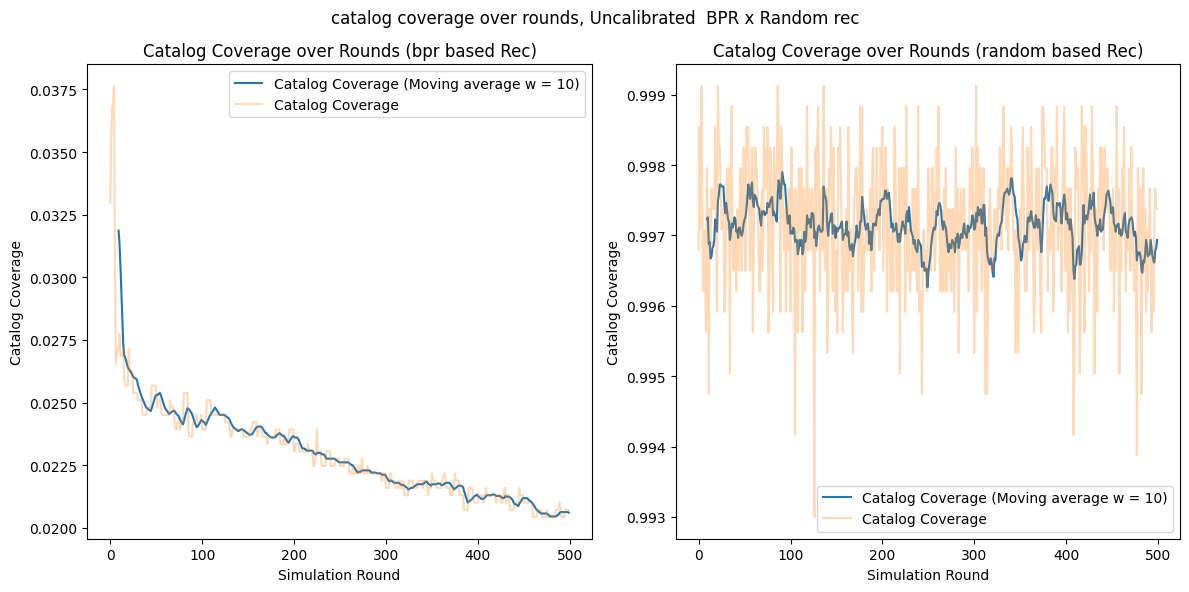

In [8]:
plot_metric_comparison(bpr_debiased, random_rec, metric_name="coverage", title="catalog coverage over rounds, Uncalibrated  BPR x Random rec", graph="line", plot_retrain_points=False,  window_size=10)

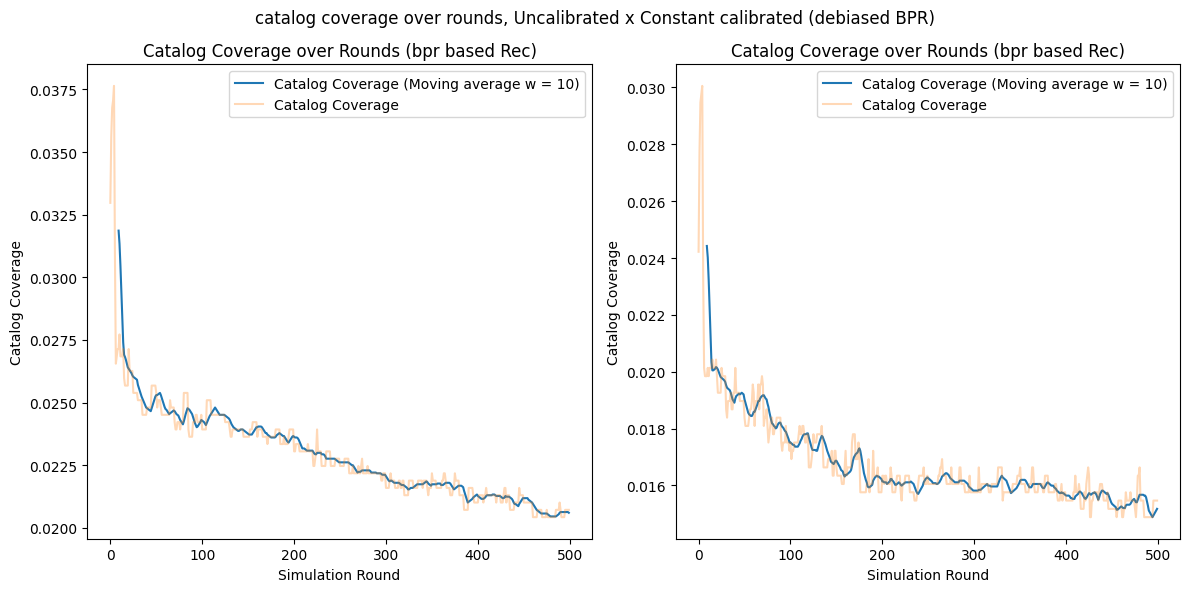

In [9]:
plot_metric_comparison(bpr_debiased, bpr_debiased_calibrated_constant, metric_name="coverage", title="catalog coverage over rounds, Uncalibrated x Constant calibrated (debiased BPR)", graph="line", plot_retrain_points=False,  window_size=10)

Catalog coverage muda ao longo do tempo porque o conceito do que é popular muda. Faz sentido.

Random rec tem cobertura super alta porque todo item é igualmente provavel de ser recomendado. Faz sentido também.

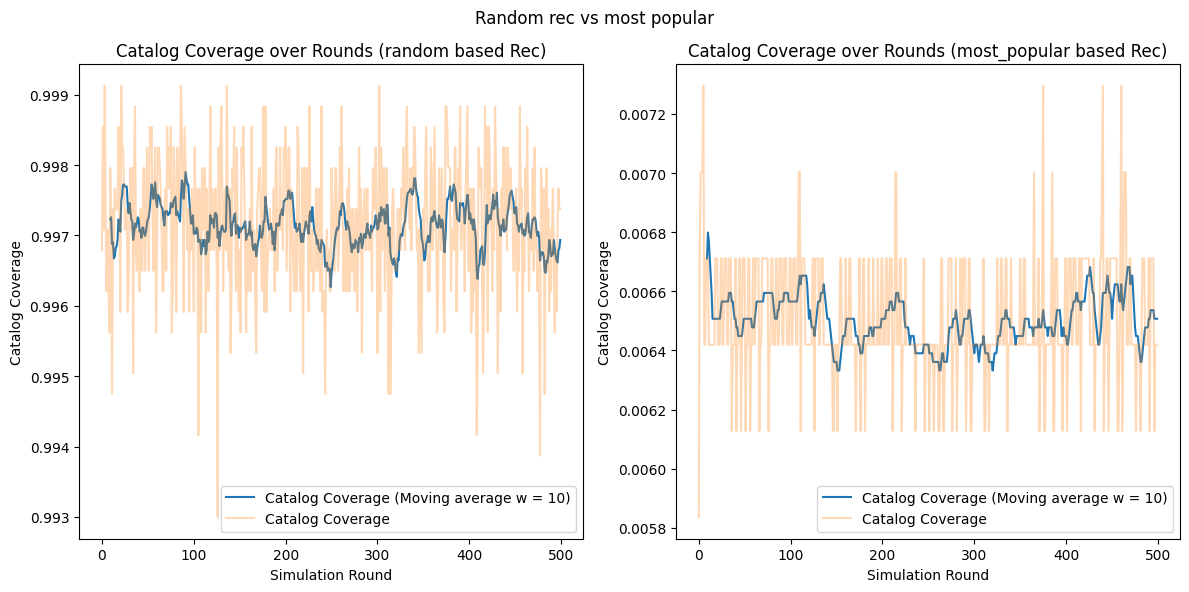

In [6]:
plot_metric_comparison(random_rec, most_popular, metric_name="coverage", title="Random rec vs most popular", graph="line", plot_retrain_points=False,  window_size=10)

## MACE

Curiosamente, o MACE do random e do most popular são ligeiramente melhores do que o bpr padrão.  Todos se mantém relativamente constantes, mas a versão calibrada apresenta clara tendência de queda: os itens recomendados passam, ao longo do tempo, se tornar mais e mais próximos ao gosto do usuário.

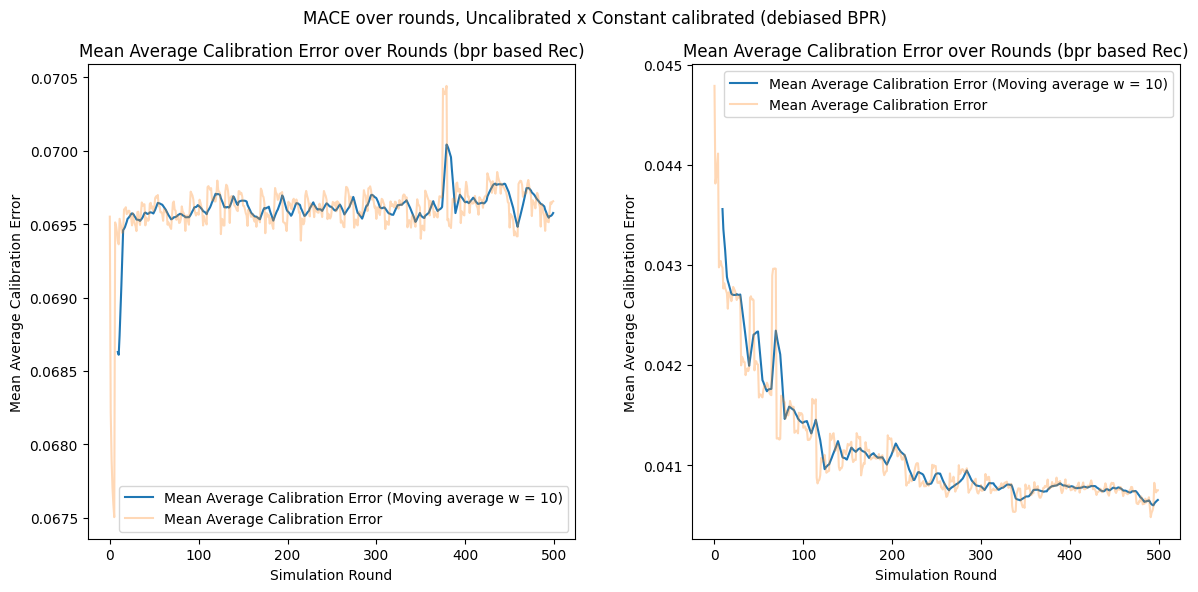

In [10]:
plot_metric_comparison(bpr_debiased, bpr_debiased_calibrated_constant, metric_name="MACE", title="MACE over rounds, Uncalibrated x Constant calibrated (debiased BPR)", graph="line", plot_retrain_points=False,  window_size=10)

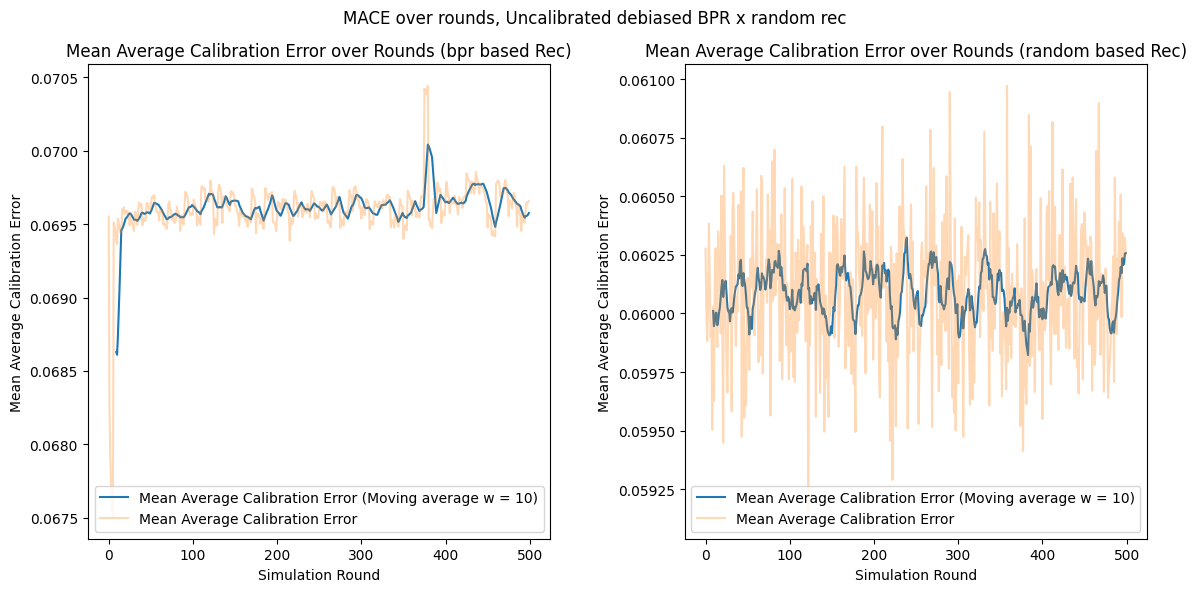

In [11]:
plot_metric_comparison(bpr_debiased, random_rec, metric_name="MACE", title="MACE over rounds, Uncalibrated debiased BPR x random rec", graph="line", plot_retrain_points=False,  window_size=10)

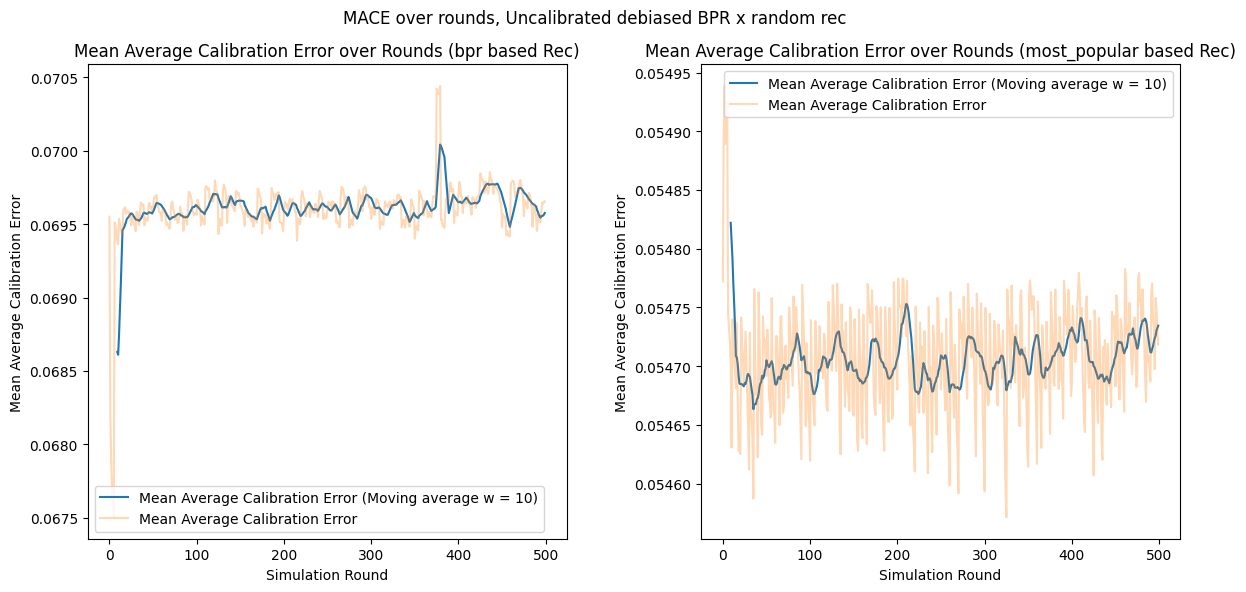

In [12]:
plot_metric_comparison(bpr_debiased, most_popular, metric_name="MACE", title="MACE over rounds, Uncalibrated debiased BPR x random rec", graph="line", plot_retrain_points=False,  window_size=10)